In [5]:
# CELL 1 — Extract EV dataset

import zipfile
import os

zip_path = "/content/archive (2).zip"
extract_path = "/content/ev_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed successfully!\n")

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

Extraction completed successfully!

/content/ev_dataset/ev_charging_station_data.csv


In [6]:
# CELL 2 — Check extracted files

import os

for root, dirs, files in os.walk("/content/ev_dataset"):
    level = root.replace("/content/ev_dataset", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

ev_dataset/
    ev_charging_station_data.csv


In [7]:
import pandas as pd

file_path = "/content/ev_dataset/ev_charging_station_data.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1317750, 33)


,timestamp,station_id,station_name,network,city,state,latitude,longitude,location_type,charger_type,...,precipitation_mm,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
0,2025-07-01 00:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,5.08,2,none,False,False,0,1,7
1,2025-07-01 00:30:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,partly_cloudy,4.72,3,none,False,False,0,1,7
2,2025-07-01 01:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,partly_cloudy,4.68,1,none,False,False,1,1,7
3,2025-07-01 01:30:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,4.78,3,none,False,False,1,1,7
4,2025-07-01 02:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,4.69,1,none,False,False,2,1,7


In [8]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['timestamp', 'station_id', 'station_name', 'network', 'city', 'state', 'latitude', 'longitude', 'location_type', 'charger_type', 'power_output_kw', 'amenities_nearby', 'ports_total', 'ports_available', 'ports_occupied', 'ports_out_of_service', 'utilization_rate', 'station_status', 'estimated_wait_time_mins', 'avg_session_duration_mins', 'current_price', 'pricing_type', 'temperature_f', 'precipitation_mm', 'weather_condition', 'gas_price_per_gallon', 'traffic_congestion_index', 'local_event', 'is_weekend', 'is_peak_hour', 'hour_of_day', 'day_of_week', 'month']

Data types:
timestamp                     object
station_id                    object
station_name                  object
network                       object
city                          object
state                         object
latitude                     float64
longitude                    float64
location_type                 object
charger_type                  object
power_output_kw              float64
amen

In [9]:
print("Dataset Shape:", df.shape)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumerical columns:")
display(df.describe())

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (1317750, 33)

Duplicate rows: 0

Numerical columns:


,latitude,longitude,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,temperature_f,precipitation_mm,gas_price_per_gallon,traffic_congestion_index,hour_of_day,day_of_week,month
count,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06,1.317750e+06
mean,3.744355e+01,-1.016788e+02,1.345880e+02,7.306667e+00,4.199560e+00,2.393753e+00,7.133538e-01,4.161674e-01,2.573585e+00,8.186490e+01,3.136559e-01,7.167426e+01,5.822979e-01,3.942132e+00,4.999762e+00,1.149869e+01,2.988958e+00,9.481161e+00
std,5.894349e+00,1.751827e+01,1.285099e+02,4.483968e+00,3.420840e+00,3.323426e+00,2.383273e+00,2.996116e-01,1.359928e+01,7.235568e+01,1.592668e-01,2.092404e+01,2.347550e+00,6.010975e-01,2.484571e+00,6.922882e+00,1.999885e+00,1.707833e+00
min,2.561943e+01,-1.228127e+02,7.200000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-02,0.000000e+00,2.100000e+01,0.000000e+00,2.010000e+01,0.000000e+00,3.280000e+00,1.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00
25%,3.348356e+01,-1.172766e+02,1.920000e+01,4.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.240000e-01,0.000000e+00,3.100000e+01,2.500000e-01,6.000000e+01,0.000000e+00,3.480000e+00,3.000000e+00,5.000000e+00,1.000000e+00,8.000000e+00
50%,3.697384e+01,-1.050262e+02,1.000000e+02,6.000000e+00,4.000000e+00,1.000000e+00,0.000000e+00,4.010000e-01,0.000000e+00,4.100000e+01,3.400000e-01,7.460000e+01,0.000000e+00,3.660000e+00,5.000000e+00,1.100000e+01,3.000000e+00,9.000000e+00
75%,4.197794e+01,-8.452968e+01,2.500000e+02,8.000000e+00,6.000000e+00,3.000000e+00,0.000000e+00,6.500000e-01,0.000000e+00,1.410000e+02,4.200000e-01,8.750000e+01,0.000000e+00,4.360000e+00,7.000000e+00,1.700000e+01,5.000000e+00,1.100000e+01
max,4.772777e+01,-7.091298e+01,3.500000e+02,2.400000e+01,2.400000e+01,2.300000e+01,2.400000e+01,9.800000e-01,1.340000e+02,2.510000e+02,6.960000e-01,1.100000e+02,6.280000e+01,5.500000e+00,1.000000e+01,2.300000e+01,6.000000e+00,1.200000e+01



First 5 rows:


,timestamp,station_id,station_name,network,city,state,latitude,longitude,location_type,charger_type,...,precipitation_mm,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
0,2025-07-01 00:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,5.08,2,none,False,False,0,1,7
1,2025-07-01 00:30:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,partly_cloudy,4.72,3,none,False,False,0,1,7
2,2025-07-01 01:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,partly_cloudy,4.68,1,none,False,False,1,1,7
3,2025-07-01 01:30:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,4.78,3,none,False,False,1,1,7
4,2025-07-01 02:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,4.69,1,none,False,False,2,1,7


In [10]:
# CELL 9 — Timestamp preprocessing

df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

print("Timestamp range:")
print("Start:", df["timestamp"].min())
print("End  :", df["timestamp"].max())

display(df[["timestamp", "station_id", "ports_available"]].head())

Timestamp range:
Start: 2025-07-01 00:00:00
End  : 2025-12-31 00:00:00


,timestamp,station_id,ports_available
0,2025-07-01,EV00001,1
1,2025-07-01,EV00094,4
2,2025-07-01,EV00131,5
3,2025-07-01,EV00054,9
4,2025-07-01,EV00079,7


In [11]:
# CELL 10 — Check time intervals

time_diff = df["timestamp"].diff().dropna()

print("Most common time intervals:")
print(time_diff.value_counts().head(10))

Most common time intervals:
timestamp
0 days 00:00:00    1308965
0 days 00:30:00       8784
Name: count, dtype: int64


In [12]:
# CELL 11 — Define features and target

features = [
    "ports_available",
    "ports_occupied",
    "ports_out_of_service",
    "utilization_rate",
    "estimated_wait_time_mins",
    "avg_session_duration_mins",
    "power_output_kw",
    "current_price",
    "temperature_f",
    "precipitation_mm",
    "gas_price_per_gallon",
    "traffic_congestion_index",
    "is_weekend",
    "is_peak_hour",
    "hour_of_day",
    "day_of_week",
    "month"
]

target = "ports_available"

model_df = df[["timestamp", "station_id"] + features].copy()

print("Features:", len(features))
print("Target:", target)
print("Shape:", model_df.shape)

display(model_df.head())

Features: 17
Target: ports_available
Shape: (1317750, 19)


,timestamp,station_id,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,power_output_kw,current_price,temperature_f,precipitation_mm,gas_price_per_gallon,traffic_congestion_index,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
0,2025-07-01,EV00001,1,0,5,0.131,0,33,19.2,0.24,98.6,0.0,5.08,2,False,False,0,1,7
1,2025-07-01,EV00094,4,0,4,0.200,0,30,350.0,0.32,82.1,0.0,4.24,1,False,False,0,1,7
2,2025-07-01,EV00131,5,1,0,0.233,0,33,350.0,0.41,100.7,0.0,3.59,2,False,False,0,1,7
3,2025-07-01,EV00054,9,1,0,0.154,0,115,7.2,0.00,96.7,0.0,3.38,3,False,False,0,1,7
4,2025-07-01,EV00079,7,1,0,0.235,0,230,125.0,0.19,72.0,4.0,4.21,2,False,False,0,1,7


In [13]:
# CELL 12 — Check time intervals within each station

station_intervals = (
    model_df
    .sort_values(["station_id", "timestamp"])
    .groupby("station_id")["timestamp"]
    .diff()
    .dropna()
)

print("Most common station-level intervals:")
print(station_intervals.value_counts().head(10))

Most common station-level intervals:
timestamp
0 days 00:30:00    1317600
Name: count, dtype: int64


In [14]:
# CELL 13 — Station statistics

station_counts = model_df["station_id"].value_counts()

print("Number of unique stations:", station_counts.nunique())
print("Total station IDs:", len(station_counts))

print("\nRecords per station:")
display(station_counts.describe())

print("\nTop 10 stations by records:")
display(station_counts.head(10))

Number of unique stations: 1
Total station IDs: 150

Records per station:


,count
count,150.0
mean,8785.0
std,0.0
min,8785.0
25%,8785.0
50%,8785.0
75%,8785.0
max,8785.0



Top 10 stations by records:


,count
station_id,
EV00001,8785
EV00094,8785
EV00131,8785
EV00054,8785
EV00079,8785
EV00066,8785
EV00093,8785
EV00042,8785
EV00043,8785


In [15]:
# CELL 14 — Check duplicate station-timestamp records

duplicates = model_df.duplicated(
    subset=["station_id", "timestamp"]
).sum()

print("Duplicate station-timestamp rows:", duplicates)

Duplicate station-timestamp rows: 0


In [16]:
# CELL 15 — Final chronological sorting

model_df = (
    model_df
    .sort_values(["station_id", "timestamp"])
    .reset_index(drop=True)
)

print("Sorting completed.")

display(
    model_df[
        ["station_id", "timestamp", "ports_available"]
    ].head(10)
)

Sorting completed.


,station_id,timestamp,ports_available
0,EV00001,2025-07-01 00:00:00,1
1,EV00001,2025-07-01 00:30:00,6
2,EV00001,2025-07-01 01:00:00,6
3,EV00001,2025-07-01 01:30:00,6
4,EV00001,2025-07-01 02:00:00,6
5,EV00001,2025-07-01 02:30:00,6
6,EV00001,2025-07-01 03:00:00,6
7,EV00001,2025-07-01 03:30:00,6
8,EV00001,2025-07-01 04:00:00,6
9,EV00001,2025-07-01 04:30:00,6


In [17]:
# CELL 16 — Chronological train/test split

train_parts = []
test_parts = []

for station_id, station_data in model_df.groupby("station_id"):
    station_data = station_data.sort_values("timestamp").reset_index(drop=True)

    split_index = int(len(station_data) * 0.80)

    train_parts.append(station_data.iloc[:split_index])
    test_parts.append(station_data.iloc[split_index:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

print("\nTraining time range:")
print(train_df["timestamp"].min(), "→", train_df["timestamp"].max())

print("\nTesting time range:")
print(test_df["timestamp"].min(), "→", test_df["timestamp"].max())

Training shape: (1054200, 19)
Testing shape : (263550, 19)

Training time range:
2025-07-01 00:00:00 → 2025-11-24 09:30:00

Testing time range:
2025-11-24 10:00:00 → 2025-12-31 00:00:00


In [18]:
# CELL 17 — Prepare training and testing data

X_train_raw = train_df[features].astype(float)
y_train_raw = train_df[target].astype(float)

X_test_raw = test_df[features].astype(float)
y_test_raw = test_df[target].astype(float)

print("X_train:", X_train_raw.shape)
print("y_train:", y_train_raw.shape)
print("X_test :", X_test_raw.shape)
print("y_test :", y_test_raw.shape)

X_train: (1054200, 17)
y_train: (1054200,)
X_test : (263550, 17)
y_test : (263550,)


In [19]:
# CELL 18 — Scale input features and target

from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train_raw)
X_test_scaled = feature_scaler.transform(X_test_raw)

y_train_scaled = target_scaler.fit_transform(
    y_train_raw.values.reshape(-1, 1)
)

y_test_scaled = target_scaler.transform(
    y_test_raw.values.reshape(-1, 1)
)

print("Feature scaling completed.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

Feature scaling completed.
X_train_scaled shape: (1054200, 17)
X_test_scaled shape : (263550, 17)


In [20]:
# CELL 19 — Prepare station-wise data for LSTM

import numpy as np

SEQUENCE_LENGTH = 48

# Convert scaled arrays to float32 to reduce RAM usage
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)

y_train_scaled = y_train_scaled.astype(np.float32)
y_test_scaled = y_test_scaled.astype(np.float32)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

print("Data type:", X_train_scaled.dtype)

X_train_scaled: (1054200, 17)
X_test_scaled : (263550, 17)
Data type: float32


In [21]:
# CELL 20 — Memory-efficient LSTM data generator

import tensorflow as tf

class StationSequenceGenerator(tf.keras.utils.Sequence):

    def __init__(
        self,
        data_df,
        X_scaled,
        y_scaled,
        sequence_length=48,
        batch_size=256
    ):

        self.X = X_scaled
        self.y = y_scaled
        self.sequence_length = sequence_length
        self.batch_size = batch_size

        # Store valid sequence starting positions
        self.indices = []

        current_position = 0

        for station_id, station_data in data_df.groupby(
            "station_id", sort=False
        ):

            n = len(station_data)

            if n > sequence_length:

                for i in range(
                    sequence_length,
                    n
                ):
                    self.indices.append(
                        current_position + i
                    )

            current_position += n

        self.indices = np.array(
            self.indices,
            dtype=np.int32
        )

    def __len__(self):

        return int(
            np.ceil(
                len(self.indices) / self.batch_size
            )
        )

    def __getitem__(self, batch_index):

        start = batch_index * self.batch_size
        end = min(
            start + self.batch_size,
            len(self.indices)
        )

        batch_indices = self.indices[start:end]

        X_batch = np.empty(
            (
                len(batch_indices),
                self.sequence_length,
                self.X.shape[1]
            ),
            dtype=np.float32
        )

        y_batch = np.empty(
            (len(batch_indices), 1),
            dtype=np.float32
        )

        for j, idx in enumerate(batch_indices):

            X_batch[j] = self.X[
                idx - self.sequence_length:idx
            ]

            y_batch[j] = self.y[idx]

        return X_batch, y_batch

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

In [22]:
# CELL 21 — Training generator

BATCH_SIZE = 256

train_generator = StationSequenceGenerator(
    train_df,
    X_train_scaled,
    y_train_scaled,
    sequence_length=SEQUENCE_LENGTH,
    batch_size=BATCH_SIZE
)

print("Training batches:", len(train_generator))
print("Batch size:", BATCH_SIZE)

Training batches: 4090
Batch size: 256


In [23]:
# CELL 22 — Create validation split

train_parts = []
validation_parts = []

for station_id, station_data in train_df.groupby("station_id"):

    station_data = station_data.sort_values(
        "timestamp"
    ).reset_index(drop=True)

    split_index = int(len(station_data) * 0.90)

    train_parts.append(
        station_data.iloc[:split_index]
    )

    validation_parts.append(
        station_data.iloc[split_index:]
    )

train_model_df = pd.concat(
    train_parts
).reset_index(drop=True)

validation_df = pd.concat(
    validation_parts
).reset_index(drop=True)

print("Training data:", train_model_df.shape)
print("Validation data:", validation_df.shape)

Training data: (948750, 19)
Validation data: (105450, 19)


In [24]:
# CELL 23 — Scale validation data using existing scalers

X_train_model_raw = train_model_df[features].astype(float)
y_train_model_raw = train_model_df[target].astype(float)

X_validation_raw = validation_df[features].astype(float)
y_validation_raw = validation_df[target].astype(float)

X_train_model_scaled = feature_scaler.transform(
    X_train_model_raw
).astype(np.float32)

y_train_model_scaled = target_scaler.transform(
    y_train_model_raw.values.reshape(-1, 1)
).astype(np.float32)

X_validation_scaled = feature_scaler.transform(
    X_validation_raw
).astype(np.float32)

y_validation_scaled = target_scaler.transform(
    y_validation_raw.values.reshape(-1, 1)
).astype(np.float32)

print("Training:", X_train_model_scaled.shape)
print("Validation:", X_validation_scaled.shape)

Training: (948750, 17)
Validation: (105450, 17)


In [25]:
# CELL 24 — Create training and validation generators

train_generator = StationSequenceGenerator(
    train_model_df,
    X_train_model_scaled,
    y_train_model_scaled,
    sequence_length=SEQUENCE_LENGTH,
    batch_size=256
)

validation_generator = StationSequenceGenerator(
    validation_df,
    X_validation_scaled,
    y_validation_scaled,
    sequence_length=SEQUENCE_LENGTH,
    batch_size=256
)

print("Training batches:", len(train_generator))
print("Validation batches:", len(validation_generator))

Training batches: 3678
Validation batches: 384


In [26]:
# CELL 25 — Verify generator

X_batch, y_batch = train_generator[0]

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

print("X batch dtype:", X_batch.dtype)
print("y batch dtype:", y_batch.dtype)

X batch shape: (256, 48, 17)
y batch shape: (256, 1)
X batch dtype: float32
y batch dtype: float32


In [27]:
# CELL 26 — Build LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(48, 17)
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# CELL 27 — Train LSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

print("\n✓ Training completed.")

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3678/3678 ━━━━━━━━━━━━━━━━━━━━ 651s 176ms/step - loss: 0.0062 - mae: 0.0494 - val_loss: 0.0051 - val_mae: 0.0460
Epoch 2/20
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 651s 177ms/step - loss: 0.0055 - mae: 0.0449 - val_loss: 0.0050 - val_mae: 0.0418
Epoch 3/20
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 657s 179ms/step - loss: 0.0053 - mae: 0.0439 - val_loss: 0.0050 - val_mae: 0.0429
Epoch 4/20
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 660s 179ms/step - loss: 0.0053 - mae: 0.0433 - val_loss: 0.0050 - val_mae: 0.0451
Epoch 5/20
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 653s 177ms/step - loss: 0.0052 - mae: 0.0430 - val_loss: 0.0050 - val_mae: 0.0421
Epoch 6/20
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 644s 175ms/step - loss: 0.0052 - mae: 0.0427 - val_loss: 0.0050 - val_mae: 0.0429
Epoch 7/20
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 642s 174ms/step - loss: 0.0052 - mae: 0.0425 - val_loss: 0.0052 - val_mae: 0.0455
Epoch 8/20
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 647s 176ms/step - loss: 0.0051 - mae: 0.0423 - val_loss: 0.0052 - val_mae: 0.0437

✓ Training complet

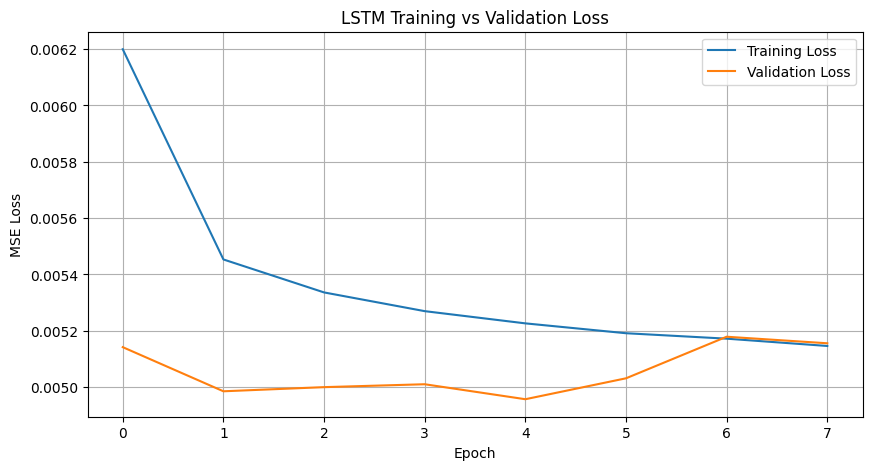

In [30]:
# CELL 28 — Plot training and validation loss

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

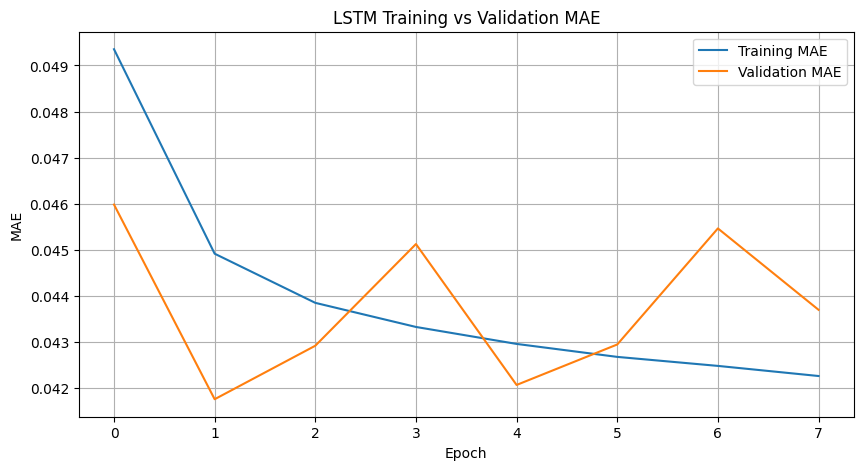

In [31]:
# CELL 29 — Plot training and validation MAE

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("LSTM Training vs Validation MAE")
plt.legend()
plt.grid(True)

plt.show()


In [32]:
# CELL 30 — Create test generator

test_generator = StationSequenceGenerator(
    test_df,
    X_test_scaled,
    y_test_scaled,
    sequence_length=SEQUENCE_LENGTH,
    batch_size=256
)

print("Test batches:", len(test_generator))

Test batches: 1002


In [33]:
# CELL 31 — Evaluate LSTM on test data

test_loss, test_mae = model.evaluate(
    test_generator,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test MAE :", test_mae)

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1002/1002 ━━━━━━━━━━━━━━━━━━━━ 68s 67ms/step - loss: 0.0048 - mae: 0.0419

Test Loss: 0.004802485462278128
Test MAE : 0.04186391457915306


In [34]:
# CELL 32 — Generate test predictions

y_pred_scaled = model.predict(
    test_generator,
    verbose=1
)

print("Prediction shape:", y_pred_scaled.shape)

1002/1002 ━━━━━━━━━━━━━━━━━━━━ 69s 68ms/step
Prediction shape: (256350, 1)


In [35]:
# CELL 33 — Convert predictions back to original scale

y_pred = target_scaler.inverse_transform(
    y_pred_scaled
).flatten()

y_actual = []

for batch_index in range(len(test_generator)):

    _, y_batch = test_generator[batch_index]

    y_actual.extend(
        y_batch.flatten()
    )

y_actual = np.array(y_actual)

y_actual = target_scaler.inverse_transform(
    y_actual.reshape(-1, 1)
).flatten()

print("Actual values:", y_actual.shape)
print("Predicted values:", y_pred.shape)

print("\nFirst 10 predictions:")
for actual, predicted in zip(y_actual[:10], y_pred[:10]):
    print(
        f"Actual: {actual:.2f} | "
        f"Predicted: {predicted:.2f}"
    )

Actual values: (256350,)
Predicted values: (256350,)

First 10 predictions:
Actual: 4.00 | Predicted: 8.61
Actual: 10.00 | Predicted: 3.30
Actual: 1.00 | Predicted: 1.60
Actual: 0.00 | Predicted: 2.45
Actual: 8.00 | Predicted: 1.50
Actual: 3.00 | Predicted: 4.18
Actual: 4.00 | Predicted: 4.21
Actual: 12.00 | Predicted: 2.17
Actual: 1.00 | Predicted: 3.18
Actual: 6.00 | Predicted: 1.36


In [36]:
# CELL 34 — Final evaluation metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_pred
    )
)

mape = mean_absolute_percentage_error(
    y_actual,
    y_pred
) * 100

r2 = r2_score(
    y_actual,
    y_pred
)

print("===== LSTM TEST RESULTS =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

===== LSTM TEST RESULTS =====
MAE  : 3.1635
RMSE : 4.3526
MAPE : 117003512499404800.00%
R²   : -0.6612


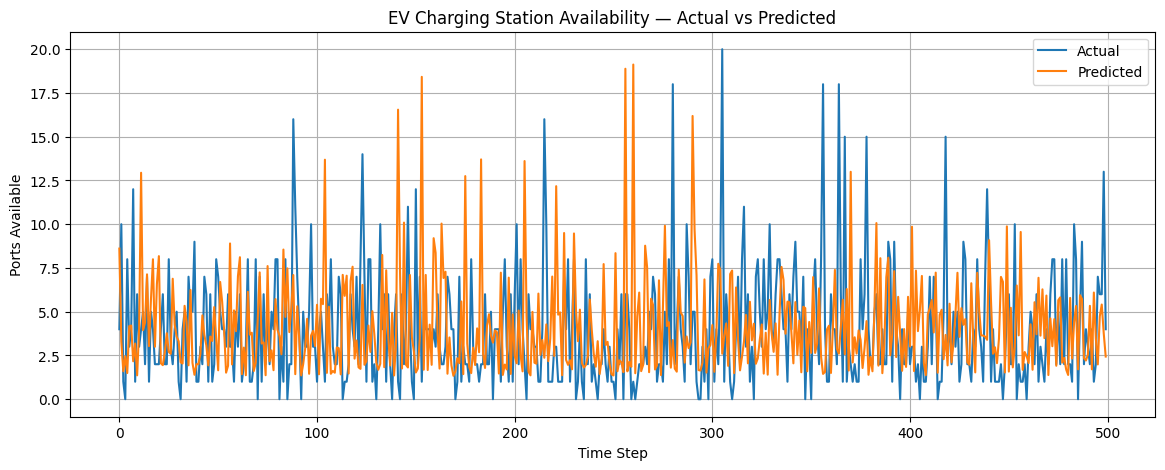

In [37]:
# CELL 35 — Actual vs Predicted

import matplotlib.pyplot as plt

N = 500

plt.figure(figsize=(14, 5))

plt.plot(
    y_actual[:N],
    label="Actual"
)

plt.plot(
    y_pred[:N],
    label="Predicted"
)

plt.xlabel("Time Step")
plt.ylabel("Ports Available")
plt.title("EV Charging Station Availability — Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.show()

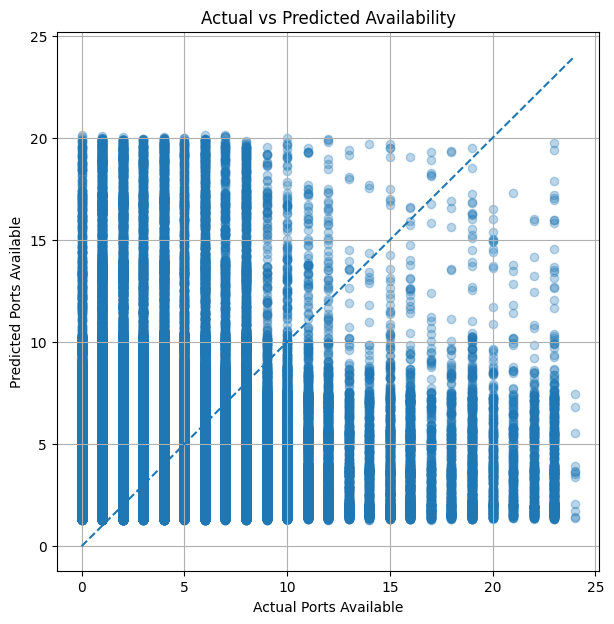

In [38]:
# CELL 36 — Actual vs Predicted Scatter Plot

plt.figure(figsize=(7, 7))

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.3
)

min_value = min(
    y_actual.min(),
    y_pred.min()
)

max_value = max(
    y_actual.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Ports Available")
plt.ylabel("Predicted Ports Available")
plt.title("Actual vs Predicted Availability")

plt.grid(True)
plt.show()

In [39]:
# CELL 37 — Correct MAPE calculation

non_zero_mask = y_actual != 0

mae_nonzero = mean_absolute_error(
    y_actual[non_zero_mask],
    y_pred[non_zero_mask]
)

rmse_nonzero = np.sqrt(
    mean_squared_error(
        y_actual[non_zero_mask],
        y_pred[non_zero_mask]
    )
)

mape_nonzero = mean_absolute_percentage_error(
    y_actual[non_zero_mask],
    y_pred[non_zero_mask]
) * 100

r2_nonzero = r2_score(
    y_actual[non_zero_mask],
    y_pred[non_zero_mask]
)

print("===== NON-ZERO TEST RESULTS =====")
print(f"MAE  : {mae_nonzero:.4f}")
print(f"RMSE : {rmse_nonzero:.4f}")
print(f"MAPE : {mape_nonzero:.2f}%")
print(f"R²   : {r2_nonzero:.4f}")

===== NON-ZERO TEST RESULTS =====
MAE  : 3.1016
RMSE : 4.3141
MAPE : 117.58%
R²   : -0.6870


In [40]:
# CELL 38 — Persistence baseline

# The first value in every generated sequence corresponds
# to the availability 48 steps before the target.
#
# For a one-step-ahead persistence baseline,
# use the most recent availability in the input sequence.

baseline_predictions = []

for batch_index in range(len(test_generator)):

    X_batch, y_batch = test_generator[batch_index]

    # ports_available is the FIRST feature
    # because it is the first item in features
    last_available = X_batch[:, -1, 0]

    baseline_predictions.extend(last_available)

baseline_predictions = np.array(
    baseline_predictions
)

baseline_predictions = target_scaler.inverse_transform(
    baseline_predictions.reshape(-1, 1)
).flatten()

print("Baseline predictions:", baseline_predictions.shape)

Baseline predictions: (256350,)


In [41]:
# CELL 39 — Evaluate persistence baseline

baseline_mae = mean_absolute_error(
    y_actual,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_actual,
    baseline_predictions
)

non_zero_baseline = y_actual != 0

baseline_mape = mean_absolute_percentage_error(
    y_actual[non_zero_baseline],
    baseline_predictions[non_zero_baseline]
) * 100

print("===== PERSISTENCE BASELINE =====")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"MAPE : {baseline_mape:.2f}%")
print(f"R²   : {baseline_r2:.4f}")

===== PERSISTENCE BASELINE =====
MAE  : 1.1960
RMSE : 2.3261
MAPE : 35.70%
R²   : 0.5256


In [42]:
# CELL 40 — Correct station-aware LSTM generator

import numpy as np
import tensorflow as tf

class StationSequenceGenerator(tf.keras.utils.Sequence):

    def __init__(
        self,
        data_df,
        X_scaled,
        y_scaled,
        sequence_length=48,
        batch_size=256,
        shuffle=False
    ):
        super().__init__()

        self.X = X_scaled
        self.y = y_scaled
        self.sequence_length = sequence_length
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.sequence_indices = []

        start = 0

        for station_id, station_data in data_df.groupby(
            "station_id",
            sort=False
        ):

            n = len(station_data)

            # Every target must have 48 previous
            # observations from the SAME station
            for i in range(
                sequence_length,
                n
            ):
                self.sequence_indices.append(
                    (
                        start,
                        start + i
                    )
                )

            start += n

        self.sequence_indices = np.array(
            self.sequence_indices,
            dtype=np.int32
        )

        self.order = np.arange(
            len(self.sequence_indices)
        )

        self.on_epoch_end()

    def __len__(self):

        return int(
            np.ceil(
                len(self.order) / self.batch_size
            )
        )

    def __getitem__(self, index):

        batch_start = (
            index * self.batch_size
        )

        batch_end = min(
            batch_start + self.batch_size,
            len(self.order)
        )

        batch_order = self.order[
            batch_start:batch_end
        ]

        batch_indices = self.sequence_indices[
            batch_order
        ]

        X_batch = np.empty(
            (
                len(batch_indices),
                self.sequence_length,
                self.X.shape[1]
            ),
            dtype=np.float32
        )

        y_batch = np.empty(
            (
                len(batch_indices),
                1
            ),
            dtype=np.float32
        )

        for j, (station_start, target_index) in enumerate(
            batch_indices
        ):

            X_batch[j] = self.X[
                target_index - self.sequence_length:
                target_index
            ]

            y_batch[j] = self.y[
                target_index
            ]

        return X_batch, y_batch

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.order)

In [43]:
# CELL 41 — Create corrected generators

train_generator = StationSequenceGenerator(
    train_model_df,
    X_train_model_scaled,
    y_train_model_scaled,
    sequence_length=48,
    batch_size=256,
    shuffle=True
)

validation_generator = StationSequenceGenerator(
    validation_df,
    X_validation_scaled,
    y_validation_scaled,
    sequence_length=48,
    batch_size=256,
    shuffle=False
)

test_generator = StationSequenceGenerator(
    test_df,
    X_test_scaled,
    y_test_scaled,
    sequence_length=48,
    batch_size=256,
    shuffle=False
)

print("Training batches   :", len(train_generator))
print("Validation batches :", len(validation_generator))
print("Testing batches    :", len(test_generator))

Training batches   : 3678
Validation batches : 384
Testing batches    : 1002


In [44]:
# CELL 41 — Create corrected generators

train_generator = StationSequenceGenerator(
    train_model_df,
    X_train_model_scaled,
    y_train_model_scaled,
    sequence_length=48,
    batch_size=256,
    shuffle=True
)

validation_generator = StationSequenceGenerator(
    validation_df,
    X_validation_scaled,
    y_validation_scaled,
    sequence_length=48,
    batch_size=256,
    shuffle=False
)

test_generator = StationSequenceGenerator(
    test_df,
    X_test_scaled,
    y_test_scaled,
    sequence_length=48,
    batch_size=256,
    shuffle=False
)

print("Training batches   :", len(train_generator))
print("Validation batches :", len(validation_generator))
print("Testing batches    :", len(test_generator))

Training batches   : 3678
Validation batches : 384
Testing batches    : 1002


In [45]:
# CELL 42 — Verify one batch

X_batch, y_batch = train_generator[0]

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

print("X dtype:", X_batch.dtype)
print("y dtype:", y_batch.dtype)

assert X_batch.shape[1] == 48
assert X_batch.shape[2] == 17
assert y_batch.shape[1] == 1

print("\n✓ Station-aware sequences are correct.")

X batch shape: (256, 48, 17)
y batch shape: (256, 1)
X dtype: float32
y dtype: float32

✓ Station-aware sequences are correct.


In [46]:
# CELL 43 — Build improved LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(48, 17)
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 48, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# CELL 44 — Train corrected LSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[early_stopping],
    verbose=1
)

print("\n✓ Corrected LSTM training completed.")

Epoch 1/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 660s 178ms/step - loss: 0.0060 - mae: 0.0486 - val_loss: 0.0051 - val_mae: 0.0458
Epoch 2/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 646s 176ms/step - loss: 0.0055 - mae: 0.0451 - val_loss: 0.0051 - val_mae: 0.0435
Epoch 3/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 647s 176ms/step - loss: 0.0054 - mae: 0.0443 - val_loss: 0.0050 - val_mae: 0.0450
Epoch 4/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 646s 176ms/step - loss: 0.0053 - mae: 0.0437 - val_loss: 0.0050 - val_mae: 0.0423
Epoch 5/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 641s 174ms/step - loss: 0.0052 - mae: 0.0433 - val_loss: 0.0054 - val_mae: 0.0499
Epoch 6/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 685s 175ms/step - loss: 0.0052 - mae: 0.0430 - val_loss: 0.0055 - val_mae: 0.0505
Epoch 7/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 651s 177ms/step - loss: 0.0052 - mae: 0.0427 - val_loss: 0.0054 - val_mae: 0.0509

✓ Corrected LSTM training completed.


In [48]:
# CELL 45 — Generate corrected LSTM predictions

y_pred_scaled = model.predict(
    test_generator,
    verbose=1
)

print("Scaled predictions:", y_pred_scaled.shape)

1002/1002 ━━━━━━━━━━━━━━━━━━━━ 74s 74ms/step
Scaled predictions: (256350, 1)


In [49]:
# CELL 46 — Inverse transform predictions

y_pred = target_scaler.inverse_transform(
    y_pred_scaled
).flatten()

y_actual = []

for batch_index in range(len(test_generator)):

    _, y_batch = test_generator[batch_index]

    y_actual.extend(
        y_batch.flatten()
    )

y_actual = np.array(y_actual)

y_actual = target_scaler.inverse_transform(
    y_actual.reshape(-1, 1)
).flatten()

print("Actual:", y_actual.shape)
print("Predicted:", y_pred.shape)

Actual: (256350,)
Predicted: (256350,)


In [50]:
# CELL 47 — Evaluate corrected LSTM

mae = mean_absolute_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_pred
    )
)

non_zero_mask = y_actual != 0

mape = mean_absolute_percentage_error(
    y_actual[non_zero_mask],
    y_pred[non_zero_mask]
) * 100

r2 = r2_score(
    y_actual,
    y_pred
)

print("===== CORRECTED LSTM TEST RESULTS =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

===== CORRECTED LSTM TEST RESULTS =====
MAE  : 0.9977
RMSE : 1.6654
MAPE : 29.74%
R²   : 0.7568


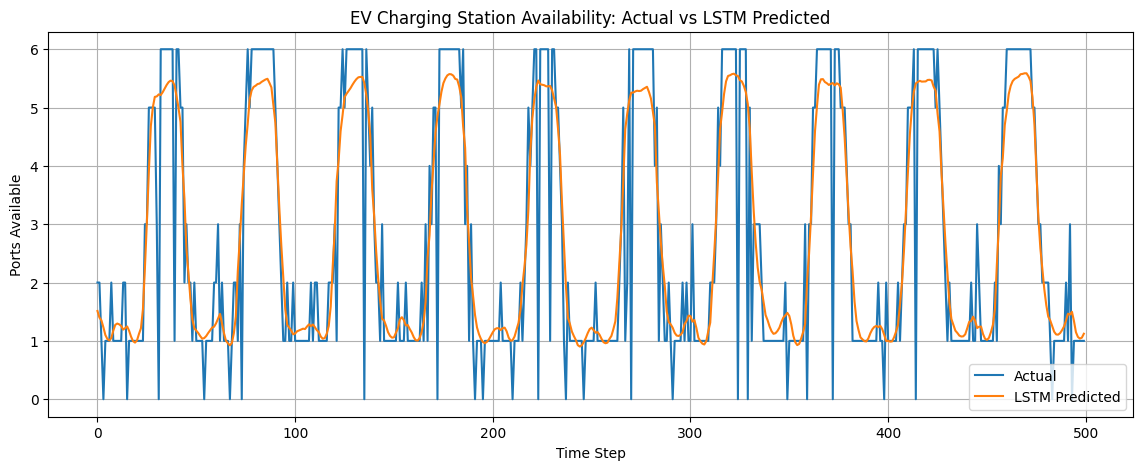

In [51]:
# CELL 49 — Actual vs Predicted Availability

import matplotlib.pyplot as plt

N = 500

plt.figure(figsize=(14, 5))

plt.plot(
    y_actual[:N],
    label="Actual"
)

plt.plot(
    y_pred[:N],
    label="LSTM Predicted"
)

plt.xlabel("Time Step")
plt.ylabel("Ports Available")
plt.title("EV Charging Station Availability: Actual vs LSTM Predicted")
plt.legend()
plt.grid(True)

plt.show()

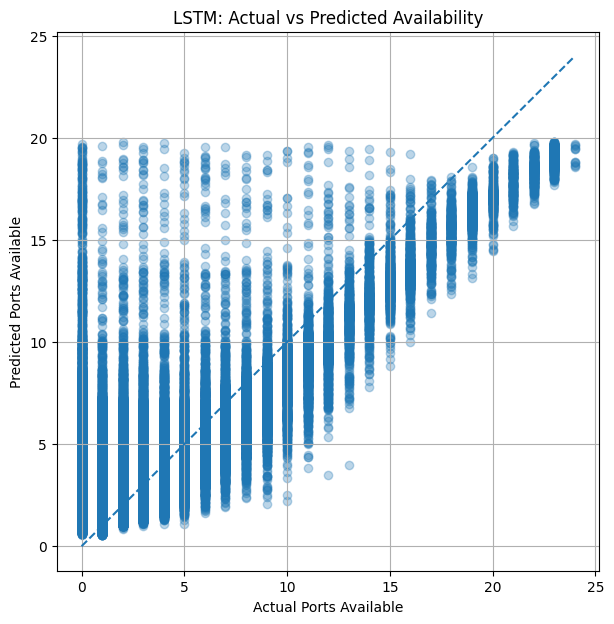

In [52]:
# CELL 50 — Actual vs Predicted Scatter Plot

plt.figure(figsize=(7, 7))

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.3
)

min_value = min(
    y_actual.min(),
    y_pred.min()
)

max_value = max(
    y_actual.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Ports Available")
plt.ylabel("Predicted Ports Available")
plt.title("LSTM: Actual vs Predicted Availability")
plt.grid(True)

plt.show()

In [53]:
# CELL 51 — Predict EV charging availability 1 hour ahead

import numpy as np
import pandas as pd

# Select a station
selected_station = test_df["station_id"].iloc[0]

# Get that station's latest records
station_data = (
    model_df[
        model_df["station_id"] == selected_station
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Take the latest 48 time steps = previous 24 hours
latest_48 = station_data.tail(48).copy()

# Scale the 17 input features
latest_scaled = feature_scaler.transform(
    latest_48[features].astype(float)
).astype(np.float32)

# Reshape for LSTM:
# (1 sample, 48 time steps, 17 features)
current_sequence = latest_scaled.reshape(
    1,
    48,
    len(features)
)

print("Selected station:", selected_station)
print("Latest timestamp:", latest_48["timestamp"].iloc[-1])
print("Input shape:", current_sequence.shape)

Selected station: EV00001
Latest timestamp: 2025-12-31 00:00:00
Input shape: (1, 48, 17)


In [54]:
# CELL 52 — Forecast next 30 minutes and next 1 hour

# Step 1: next 30-minute prediction
next_30_scaled = model.predict(
    current_sequence,
    verbose=0
)

next_30 = target_scaler.inverse_transform(
    next_30_scaled
)[0, 0]

# For the 1-hour forecast, we need to move
# the sequence forward by one step.

# Copy the latest feature row
next_input = current_sequence.copy()

# Update the ports_available feature with
# the predicted next-30-minute value.
next_input[0, -1, 0] = (
    target_scaler.transform(
        np.array([[next_30]])
    )[0, 0]
)

# Predict next 30-minute step again
next_60_scaled = model.predict(
    next_input,
    verbose=0
)

next_60 = target_scaler.inverse_transform(
    next_60_scaled
)[0, 0]

last_timestamp = latest_48["timestamp"].iloc[-1]

print("Station:", selected_station)
print()
print(
    "Current time:",
    last_timestamp
)

print(
    "Next 30 min:",
    last_timestamp + pd.Timedelta(minutes=30)
)

print(
    "Predicted ports available:",
    round(next_30, 2)
)

print()
print(
    "Next 1 hour:",
    last_timestamp + pd.Timedelta(hours=1)
)

print(
    "Predicted ports available:",
    round(next_60, 2)
)

Station: EV00001

Current time: 2025-12-31 00:00:00
Next 30 min: 2025-12-31 00:30:00
Predicted ports available: 5.28

Next 1 hour: 2025-12-31 01:00:00
Predicted ports available: 5.3


CELL 53 — Vanilla LSTM

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

vanilla_lstm = Sequential([
    LSTM(
        64,
        input_shape=(48, 17)
    ),
    Dense(1)
])

vanilla_lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

vanilla_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

vanilla_history = vanilla_lstm.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[vanilla_early_stopping],
    verbose=1
)

Epoch 1/15


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3678/3678 ━━━━━━━━━━━━━━━━━━━━ 390s 105ms/step - loss: 0.0058 - mae: 0.0470 - val_loss: 0.0053 - val_mae: 0.0411
Epoch 2/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 374s 102ms/step - loss: 0.0054 - mae: 0.0443 - val_loss: 0.0050 - val_mae: 0.0450
Epoch 3/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 369s 100ms/step - loss: 0.0053 - mae: 0.0435 - val_loss: 0.0049 - val_mae: 0.0411
Epoch 4/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 367s 100ms/step - loss: 0.0052 - mae: 0.0429 - val_loss: 0.0050 - val_mae: 0.0410
Epoch 5/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 368s 100ms/step - loss: 0.0051 - mae: 0.0424 - val_loss: 0.0051 - val_mae: 0.0413
Epoch 6/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 369s 100ms/step - loss: 0.0051 - mae: 0.0422 - val_loss: 0.0049 - val_mae: 0.0410
Epoch 7/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 370s 101ms/step - loss: 0.0051 - mae: 0.0420 - val_loss: 0.0048 - val_mae: 0.0409
Epoch 8/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 371s 101ms/step - loss: 0.0051 - mae: 0.0419 - val_loss: 0.0048 - val_mae: 0.0408
Epoch 9/15
3678/367

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_vanilla_scaled = vanilla_lstm.predict(
    test_generator,
    verbose=1
)

y_pred_vanilla = target_scaler.inverse_transform(
    y_pred_vanilla_scaled
).flatten()

y_test_vanilla = target_scaler.inverse_transform(
    np.concatenate(
        [test_generator[i][1] for i in range(len(test_generator))],
        axis=0
    )
).flatten()

mae_vanilla = mean_absolute_error(
    y_test_vanilla,
    y_pred_vanilla
)

rmse_vanilla = np.sqrt(
    mean_squared_error(
        y_test_vanilla,
        y_pred_vanilla
    )
)

mask = y_test_vanilla != 0

mape_vanilla = np.mean(
    np.abs(
        (y_test_vanilla[mask] - y_pred_vanilla[mask])
        / y_test_vanilla[mask]
    )
) * 100

r2_vanilla = r2_score(
    y_test_vanilla,
    y_pred_vanilla
)

print("Vanilla LSTM Results")
print("--------------------")
print(f"MAE  : {mae_vanilla:.4f}")
print(f"RMSE : {rmse_vanilla:.4f}")
print(f"MAPE : {mape_vanilla:.2f}%")
print(f"R²   : {r2_vanilla:.4f}")

1002/1002 ━━━━━━━━━━━━━━━━━━━━ 44s 43ms/step
Vanilla LSTM Results
--------------------
MAE  : 0.9487
RMSE : 1.6314
MAPE : 28.81%
R²   : 0.7666


CELL 55 — Stacked LSTM

In [57]:
stacked_lstm = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(48, 17)
    ),
    LSTM(32),
    Dense(1)
])

stacked_lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

stacked_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

stacked_history = stacked_lstm.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[stacked_early_stopping],
    verbose=1
)

Epoch 1/15


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3678/3678 ━━━━━━━━━━━━━━━━━━━━ 627s 170ms/step - loss: 0.0058 - mae: 0.0468 - val_loss: 0.0053 - val_mae: 0.0425
Epoch 2/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 693s 173ms/step - loss: 0.0053 - mae: 0.0441 - val_loss: 0.0051 - val_mae: 0.0457
Epoch 3/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 611s 166ms/step - loss: 0.0053 - mae: 0.0434 - val_loss: 0.0049 - val_mae: 0.0405
Epoch 4/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 619s 168ms/step - loss: 0.0052 - mae: 0.0429 - val_loss: 0.0051 - val_mae: 0.0383
Epoch 5/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 609s 166ms/step - loss: 0.0051 - mae: 0.0425 - val_loss: 0.0049 - val_mae: 0.0421
Epoch 6/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 630s 171ms/step - loss: 0.0051 - mae: 0.0422 - val_loss: 0.0049 - val_mae: 0.0412
Epoch 7/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 603s 164ms/step - loss: 0.0051 - mae: 0.0420 - val_loss: 0.0050 - val_mae: 0.0386
Epoch 8/15
3678/3678 ━━━━━━━━━━━━━━━━━━━━ 619s 168ms/step - loss: 0.0051 - mae: 0.0418 - val_loss: 0.0049 - val_mae: 0.0408
Epoch 9/15
3678/367

CELL 56 — Evaluate Stacked LSTM

In [58]:
y_pred_stacked_scaled = stacked_lstm.predict(
    test_generator,
    verbose=1
)

y_pred_stacked = target_scaler.inverse_transform(
    y_pred_stacked_scaled
).flatten()

y_test_stacked = target_scaler.inverse_transform(
    np.concatenate(
        [test_generator[i][1] for i in range(len(test_generator))],
        axis=0
    )
).flatten()

mae_stacked = mean_absolute_error(
    y_test_stacked,
    y_pred_stacked
)

rmse_stacked = np.sqrt(
    mean_squared_error(
        y_test_stacked,
        y_pred_stacked
    )
)

mask = y_test_stacked != 0

mape_stacked = np.mean(
    np.abs(
        (y_test_stacked[mask] - y_pred_stacked[mask])
        / y_test_stacked[mask]
    )
) * 100

r2_stacked = r2_score(
    y_test_stacked,
    y_pred_stacked
)

print("Stacked LSTM Results")
print("--------------------")
print(f"MAE  : {mae_stacked:.4f}")
print(f"RMSE : {rmse_stacked:.4f}")
print(f"MAPE : {mape_stacked:.2f}%")
print(f"R²   : {r2_stacked:.4f}")

1002/1002 ━━━━━━━━━━━━━━━━━━━━ 70s 69ms/step
Stacked LSTM Results
--------------------
MAE  : 1.0056
RMSE : 1.6320
MAPE : 29.20%
R²   : 0.7665


CELL 58 — Training vs Validation Loss

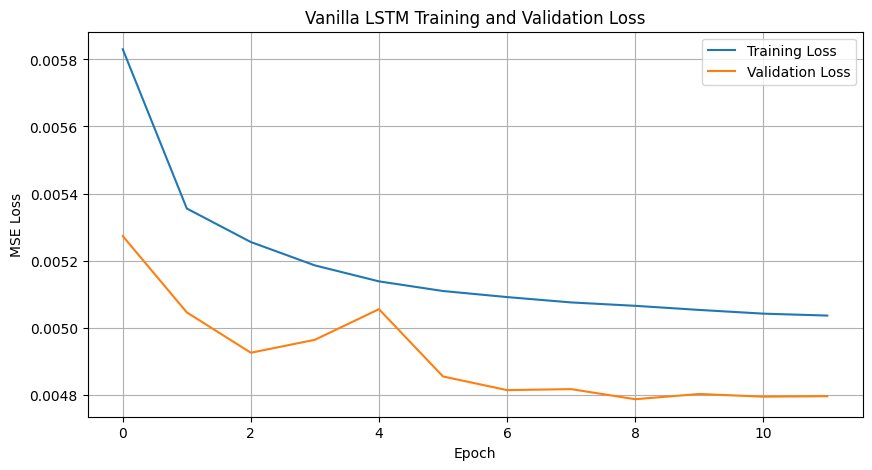

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    vanilla_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    vanilla_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Vanilla LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

CELL 59 — Training vs Validation MAE

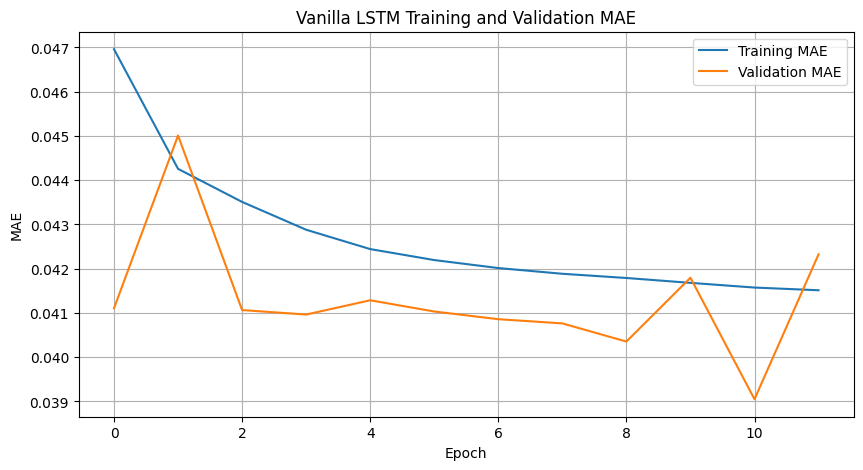

In [60]:
plt.figure(figsize=(10, 5))

plt.plot(
    vanilla_history.history["mae"],
    label="Training MAE"
)

plt.plot(
    vanilla_history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Vanilla LSTM Training and Validation MAE")
plt.legend()
plt.grid(True)

plt.show()

CELL 60 — Actual vs Predicted

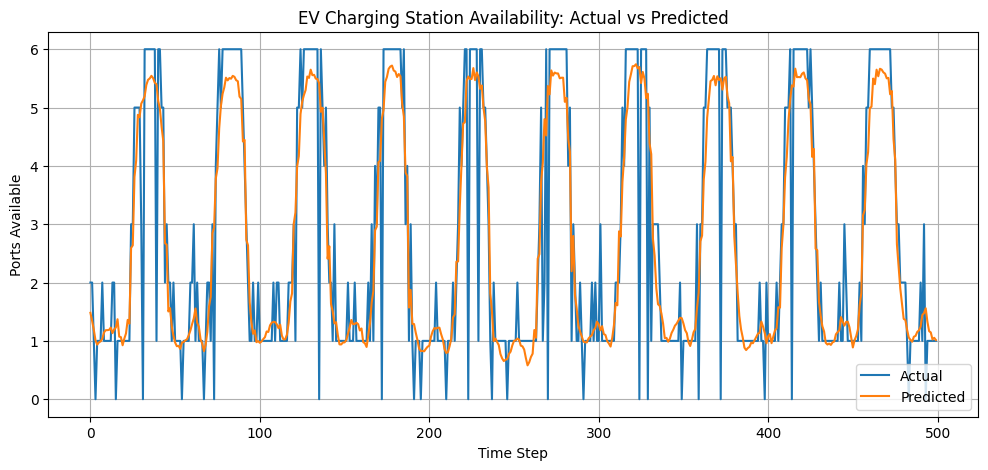

In [61]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_vanilla[:500],
    label="Actual"
)

plt.plot(
    y_pred_vanilla[:500],
    label="Predicted"
)

plt.xlabel("Time Step")
plt.ylabel("Ports Available")
plt.title("EV Charging Station Availability: Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.show()

CELL 61 — Calculate Residuals

In [62]:
residuals = y_test_vanilla - y_pred_vanilla

print("Residual Statistics")
print("-------------------")
print(f"Mean Residual : {np.mean(residuals):.4f}")
print(f"Std Residual  : {np.std(residuals):.4f}")
print(f"Mean Absolute Error : {np.mean(np.abs(residuals)):.4f}")

Residual Statistics
-------------------
Mean Residual : -0.0406
Std Residual  : 1.6309
Mean Absolute Error : 0.9487


CELL 62 — Residual Distribution

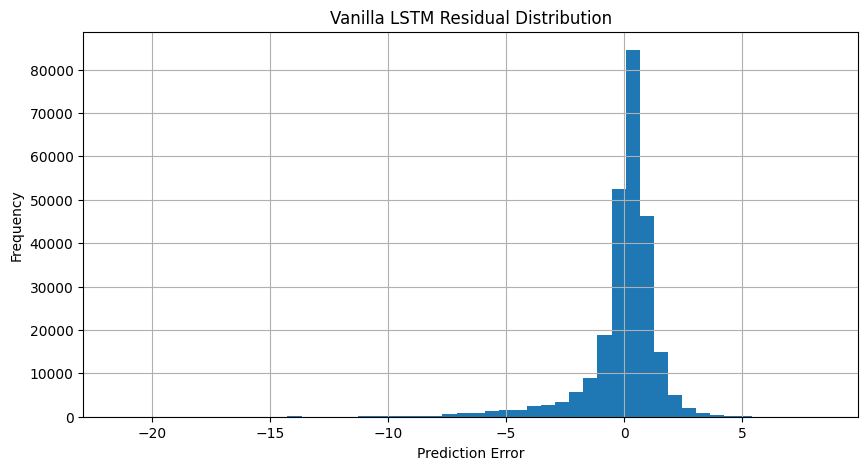

In [63]:
plt.figure(figsize=(10, 5))

plt.hist(
    residuals,
    bins=50
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Vanilla LSTM Residual Distribution")
plt.grid(True)

plt.show()

CELL 63 — Residuals Over Time

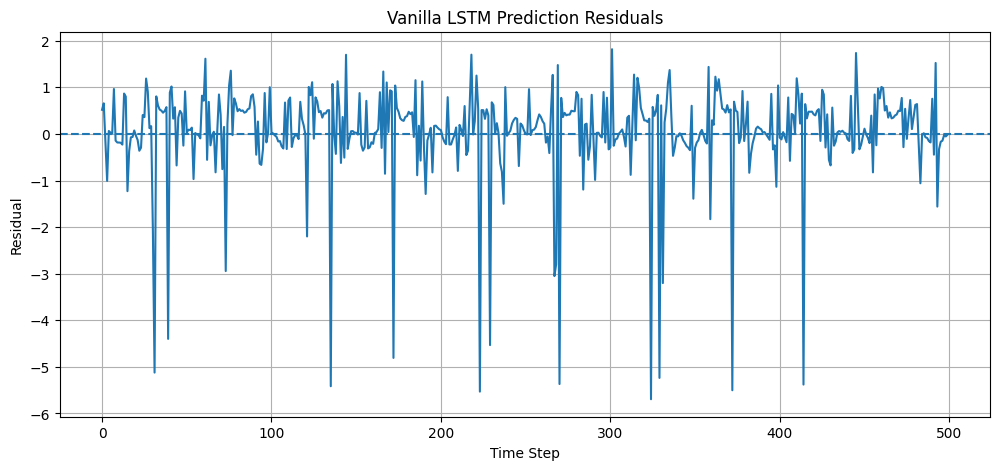

In [64]:
plt.figure(figsize=(12, 5))

plt.plot(
    residuals[:500]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time Step")
plt.ylabel("Residual")
plt.title("Vanilla LSTM Prediction Residuals")
plt.grid(True)

plt.show()

# 30-Minute and 60-Minute Prediction

Your dataset has 30-minute intervals.

Therefore:

1 step = 30 minutes
2 steps = 60 minutes

We will use the latest 48 observations = previous 24 hours.

CELL 64 — Select Station and Latest 48 Records

In [65]:
station_id = model_df["station_id"].iloc[0]

station_history = (
    model_df[
        model_df["station_id"] == station_id
    ]
    .sort_values("timestamp")
    .tail(48)
    .copy()
)

print("Station:", station_id)
print("Last timestamp:", station_history["timestamp"].iloc[-1])
print("Sequence shape:", station_history[features].shape)

Station: EV00001
Last timestamp: 2025-12-31 00:00:00
Sequence shape: (48, 17)


CELL 65 — Prepare Sequence

In [66]:
latest_sequence = station_history[features].astype(float)

latest_sequence_scaled = feature_scaler.transform(
    latest_sequence
).astype(np.float32)

current_sequence = latest_sequence_scaled.reshape(
    1,
    48,
    17
)

print("Model input shape:", current_sequence.shape)

Model input shape: (1, 48, 17)


CELL 66 — Predict Next 30 Minutes

In [67]:
next_30_scaled = vanilla_lstm.predict(
    current_sequence,
    verbose=0
)

next_30 = target_scaler.inverse_transform(
    next_30_scaled
)[0, 0]

print(f"Predicted ports available after 30 minutes: {next_30:.2f}")

Predicted ports available after 30 minutes: 4.96


CELL 67 — Predict Next 60 Minutes

In [68]:
sequence_60 = current_sequence.copy()

next_row = sequence_60[:, -1, :].copy()

ports_available_index = features.index(
    "ports_available"
)

next_row[0, ports_available_index] = (
    feature_scaler.transform(
        [[next_30 if i == ports_available_index else 0
          for i in range(len(features))]]
    )[0, ports_available_index]
)

sequence_60 = np.concatenate(
    [
        sequence_60[:, 1:, :],
        next_row.reshape(1, 1, 17)
    ],
    axis=1
)

next_60_scaled = vanilla_lstm.predict(
    sequence_60,
    verbose=0
)

next_60 = target_scaler.inverse_transform(
    next_60_scaled
)[0, 0]

print(f"Predicted ports available after 60 minutes: {next_60:.2f}")

Predicted ports available after 60 minutes: 5.23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


CELL 68 — Save Model

In [69]:
vanilla_lstm.save(
    "/content/ev_charging_vanilla_lstm.keras"
)

print("Final Vanilla LSTM model saved successfully.")

Final Vanilla LSTM model saved successfully.


CELL 69 — Save Scalers

In [70]:
import joblib

joblib.dump(
    feature_scaler,
    "/content/ev_feature_scaler.pkl"
)

joblib.dump(
    target_scaler,
    "/content/ev_target_scaler.pkl"
)

print("Scalers saved successfully.")

Scalers saved successfully.


CELL 70 — Final Results Table

In [71]:
final_results = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Vanilla LSTM",
        "Stacked LSTM",
        "LSTM + Dropout"
    ],
    "MAE": [
        1.1960,
        0.9487,
        1.0056,
        0.9977
    ],
    "RMSE": [
        2.3261,
        1.6314,
        1.6320,
        1.6654
    ],
    "MAPE (%)": [
        35.70,
        28.81,
        29.20,
        29.74
    ],
    "R2": [
        0.5256,
        0.7666,
        0.7665,
        0.7568
    ]
})

final_results

,Model,MAE,RMSE,MAPE (%),R2
0,Persistence Baseline,1.1960,2.3261,35.70,0.5256
1,Vanilla LSTM,0.9487,1.6314,28.81,0.7666
2,Stacked LSTM,1.0056,1.6320,29.20,0.7665
3,LSTM + Dropout,0.9977,1.6654,29.74,0.7568


# **EV Charging Station Availability Prediction Using LSTM**

The system uses historical EV charging station data to predict future charging-port availability. A 48-step historical window, representing the previous 24 hours, is used as input to the LSTM models. Three LSTM architectures—Vanilla LSTM, Stacked LSTM, and LSTM with Dropout—were experimentally compared against a persistence baseline.

The Vanilla LSTM achieved MAE = 0.9487, RMSE = 1.6314, MAPE = 28.81%, and R² = 0.7666 on the test set. It therefore serves as the current final model for the project. The model can also generate recursive 30-minute and 60-minute availability forecasts.